# Task 1
Модифікуйте CNN із практики.
* Додайте шар BatchNorm2d після кожного Conv2d.
* Використовуйте Dropout(p=0.3) після активації ReLU.
* Навчіть мережу на тих самих даних 10 епох.

In [17]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

import torch.nn as nn
import torch.optim as optim

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(16 * 13 * 13, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x

model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

class ImprovedNN(nn.Module):
    def __init__(self):
        super(ImprovedNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(16 * 13 * 13, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x

improved_model = ImprovedNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(improved_model.parameters(), lr=0.001)

# Task 2
Додайте контроль градієнтів.
* Застосуйте обрізку градієнтів (torch.nn.utils.clip_grad_norm_) з максимальним значенням 1.0.
* Зафіксуйте зміну втрат за епохами.



In [20]:
optimizer_base = optim.Adam(model.parameters(), lr=0.001)
optimizer_improved = optim.Adam(improved_model.parameters(), lr=0.001)

epochs = 10
improved_losses = {}
losses = {}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer_base.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_base.step()
        running_loss += loss.item()
        
    losses[epoch + 1] = running_loss / len(train_loader)
    print(f'Base epoch {epoch + 1}, Loss: {losses[epoch + 1]:.4f}')

for epoch in range(epochs):
    improved_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer_improved.zero_grad()
        outputs = improved_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(improved_model.parameters(), max_norm=1.0)
        
        optimizer_improved.step()
        running_loss += loss.item()
        
    improved_losses[epoch + 1] = running_loss / len(train_loader)
    print(f'Improved Epoch {epoch + 1}, Loss: {improved_losses[epoch + 1]:.4f}')

Base epoch 1, Loss: 0.2361
Base epoch 2, Loss: 0.0892
Base epoch 3, Loss: 0.0658
Base epoch 4, Loss: 0.0547
Base epoch 5, Loss: 0.0472
Base epoch 6, Loss: 0.0408
Base epoch 7, Loss: 0.0371
Base epoch 8, Loss: 0.0325
Base epoch 9, Loss: 0.0298
Base epoch 10, Loss: 0.0253
Improved Epoch 1, Loss: 0.0336
Improved Epoch 2, Loss: 0.0299
Improved Epoch 3, Loss: 0.0288
Improved Epoch 4, Loss: 0.0269
Improved Epoch 5, Loss: 0.0260
Improved Epoch 6, Loss: 0.0253
Improved Epoch 7, Loss: 0.0231
Improved Epoch 8, Loss: 0.0230
Improved Epoch 9, Loss: 0.0211
Improved Epoch 10, Loss: 0.0204


# Task 3
Побудуйте порівняльний графік:
* Модель без нормалізації.
* Модель із BatchNorm і Dropout.

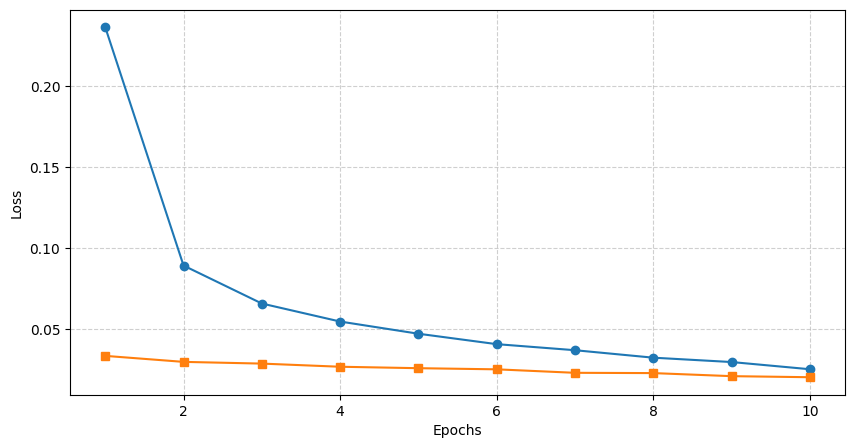

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

old_loss_values = [float(list(v)[0]) if isinstance(v, set) else float(v) for v in losses.values()]

ax.plot(list(losses.keys()), old_loss_values, marker='o')

ax.plot(list(improved_losses.keys()), list(improved_losses.values()), marker='s')

ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Task 4
* Оформіть таблицю порівняння

In [24]:
from IPython.display import Markdown as md

def evaluate_model(eval_model, loader):
    eval_model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    
    with torch.no_grad():
        for images, labels in loader:
            outputs = eval_model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    acc = 100 * correct / total
    avg_loss = running_loss / len(loader)
    return acc, avg_loss

base_acc, base_loss = evaluate_model(model, test_loader)
imp_acc, imp_loss = evaluate_model(improved_model, test_loader)

table_md = f"""
| Configuration | Accuracy | Loss | Notes |
|---|---|---|---|
| No Normalization | {base_acc:.2f}% | {base_loss:.4f} | base model |
| BatchNorm + Dropout | {imp_acc:.2f}% | {imp_loss:.4f} | improved stability |
"""
md(table_md)


| Configuration | Accuracy | Loss | Notes |
|---|---|---|---|
| No Normalization | 98.17% | 0.0569 | base model |
| BatchNorm + Dropout | 98.42% | 0.0552 | improved stability |
